# Machine Failure Classification from Sensor Data

This notebook explores clustering, label-guided, and supervised approaches for assigning failure labels to machine breakdowns based on 20 sensor measurements.
The dataset contains 40 expert-labeled failures and 1560 unlabeled failures.

## 1. Data Overview and Preparation

In this section, I load the dataset, inspect its structure, and separate the labeled and unlabeled machine failures.
I also prepare the sensor feature matrix for downstream clustering and classification experiments.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/data_sensors.csv")

In [3]:
df.head()

,Sensor 0,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Sensor 9,...,Sensor 11,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Label
0,-0.545785,-0.639964,0.323172,0.870056,0.589634,-0.654516,0.758626,-0.944226,-0.361981,-0.738958,...,0.367026,-0.684776,-0.442127,-0.797051,-0.849937,0.109651,0.275428,0.724551,-0.957438,NaN
1,0.291232,-0.188508,-0.266294,-0.931173,0.990036,-0.782436,-0.356253,0.777890,0.864639,0.510940,...,-0.144257,-0.403463,-0.029867,-0.876624,0.976521,0.983823,-0.095941,0.987311,0.245192,NaN
2,0.680580,0.423410,0.734204,-0.023014,0.639396,-0.495548,-0.373933,-0.842535,-0.228202,-0.330048,...,-0.675210,0.634603,-0.317718,-0.362630,-0.658235,0.290307,-0.560638,-0.477552,-0.206955,NaN
3,0.055538,0.116893,0.421156,0.154056,-0.107440,-0.618401,-0.915526,0.967082,-0.205136,0.591844,...,-0.373325,-0.306537,0.161707,-0.757658,-0.838197,-0.658364,0.210658,0.204989,0.663093,NaN
4,0.521701,0.066350,0.285818,0.083620,0.166119,0.387446,0.205991,-0.266857,-0.288621,0.542669,...,-0.176694,0.727822,0.274874,-0.412379,-0.657580,0.726756,0.283499,0.579462,-0.524631,NaN


In [4]:
df.shape

(1600, 21)

In [5]:
df.columns

Index(['Sensor 0', 'Sensor 1', 'Sensor 2', 'Sensor 3', 'Sensor 4', 'Sensor 5',
       'Sensor 6', 'Sensor 7', 'Sensor 8', 'Sensor 9', 'Sensor 10',
       'Sensor 11', 'Sensor 12', 'Sensor 13', 'Sensor 14', 'Sensor 15',
       'Sensor 16', 'Sensor 17', 'Sensor 18', 'Sensor 19', 'Label'],
      dtype='str')

In [6]:
df["Label"].count(), df["Label"].isna().sum()

(np.int64(40), np.int64(1560))

In [7]:
df["Label"].value_counts(dropna=False)

Label
NaN    1560
3.0      20
2.0      10
1.0      10
Name: count, dtype: int64

In [8]:
labeled_df = df[df["Label"].notna()]
unlabeled_df = df[df["Label"].isna()]

labeled_df.shape, unlabeled_df.shape

((40, 21), (1560, 21))

In [9]:
sensor_columns = [col for col in df.columns if col.startswith("Sensor")]

X = df[sensor_columns]
y = df["Label"]

X.shape, y.shape

((1600, 20), (1600,))

In [10]:
X.isna().sum()

Sensor 0     0
Sensor 1     0
Sensor 2     0
Sensor 3     0
Sensor 4     0
Sensor 5     0
Sensor 6     0
Sensor 7     0
Sensor 8     0
Sensor 9     0
Sensor 10    0
Sensor 11    0
Sensor 12    0
Sensor 13    0
Sensor 14    0
Sensor 15    0
Sensor 16    0
Sensor 17    0
Sensor 18    0
Sensor 19    0
dtype: int64

In [11]:
X.describe()

,Sensor 0,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Sensor 9,Sensor 10,Sensor 11,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19
count,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000
mean,-0.003901,0.010692,0.003611,0.016913,0.006504,-0.035332,0.002607,-0.023096,0.014207,0.001201,-0.008101,-0.000107,0.006054,-0.003777,0.003583,0.009220,0.026797,0.018740,0.018144,0.010668
std,0.578326,0.580784,0.359632,0.583571,0.570841,0.593607,0.572523,0.588614,0.579928,0.602691,0.577587,0.584802,0.577892,0.359788,0.584293,0.582116,0.569598,0.578555,0.583309,0.576219
min,-0.998098,-0.992518,-0.800000,-0.999775,-0.999870,-0.999669,-0.996949,-0.998761,-0.998044,-0.999523,-0.998975,-0.999330,-0.996221,-0.800000,-0.998908,-0.998526,-0.999408,-0.998213,-0.999880,-0.998559
25%,-0.507756,-0.488596,-0.259969,-0.504151,-0.485490,-0.576116,-0.493367,-0.531029,-0.473253,-0.559439,-0.504933,-0.514553,-0.524190,-0.265276,-0.510638,-0.488482,-0.457106,-0.505591,-0.478406,-0.470953
50%,0.004809,0.017735,0.000516,0.051528,0.000811,-0.051875,0.015700,-0.043717,0.004869,0.034202,-0.024177,0.009776,0.024858,-0.005893,0.031814,0.006501,0.038331,0.009060,0.032383,0.020862
75%,0.476584,0.513715,0.270990,0.512762,0.495880,0.481036,0.484419,0.490271,0.503751,0.547635,0.501495,0.516638,0.503594,0.259134,0.522166,0.530700,0.513615,0.537619,0.543224,0.510085
max,0.999610,0.999463,0.800000,0.999733,0.992920,0.996972,0.999369,0.999376,0.999143,0.999618,0.999918,0.995784,0.998642,0.800000,0.998700,0.997060,0.995780,0.999772,0.999192,0.999967


## 2. Exploratory Visualization with PCA

To get an initial sense of the structure of the data, I project the 20-dimensional sensor space into 2 dimensions using PCA.
This helps assess whether the known failure classes appear naturally separable in the raw feature space.

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [14]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Label"] = y
pca_df.head()

,PC1,PC2,Label
0,-0.824192,-0.467667,NaN
1,0.621474,2.770419,NaN
2,0.931716,-0.157073,NaN
3,0.004815,-0.622132,NaN
4,-0.207360,0.566636,NaN


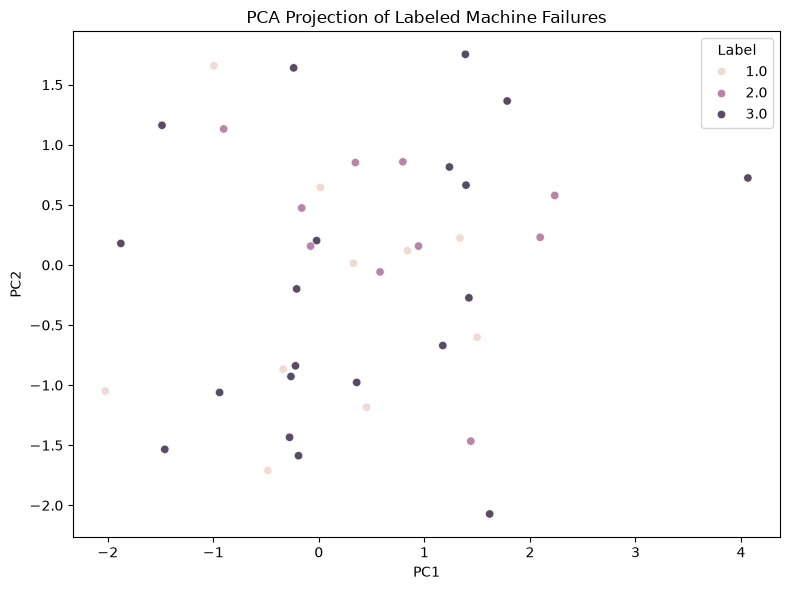

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Label", alpha=0.8)
plt.title("PCA Projection of Labeled Machine Failures")
plt.tight_layout()
plt.savefig("../outputs/pca_labeled_failures.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Unsupervised Clustering Baselines

I first test whether the machine failures can be grouped without using any label information.
To do this, I evaluate several unsupervised clustering methods on the sensor data and compare how well they align with the known failure labels.

### 3.1 KMeans Clustering

In [16]:
from sklearn.cluster import KMeans

In [17]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [18]:
results_df = df.copy()
results_df["Cluster"] = clusters

results_df.head()

,Sensor 0,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Sensor 9,...,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Label,Cluster
0,-0.545785,-0.639964,0.323172,0.870056,0.589634,-0.654516,0.758626,-0.944226,-0.361981,-0.738958,...,-0.684776,-0.442127,-0.797051,-0.849937,0.109651,0.275428,0.724551,-0.957438,NaN,0
1,0.291232,-0.188508,-0.266294,-0.931173,0.990036,-0.782436,-0.356253,0.777890,0.864639,0.510940,...,-0.403463,-0.029867,-0.876624,0.976521,0.983823,-0.095941,0.987311,0.245192,NaN,2
2,0.680580,0.423410,0.734204,-0.023014,0.639396,-0.495548,-0.373933,-0.842535,-0.228202,-0.330048,...,0.634603,-0.317718,-0.362630,-0.658235,0.290307,-0.560638,-0.477552,-0.206955,NaN,1
3,0.055538,0.116893,0.421156,0.154056,-0.107440,-0.618401,-0.915526,0.967082,-0.205136,0.591844,...,-0.306537,0.161707,-0.757658,-0.838197,-0.658364,0.210658,0.204989,0.663093,NaN,2
4,0.521701,0.066350,0.285818,0.083620,0.166119,0.387446,0.205991,-0.266857,-0.288621,0.542669,...,0.727822,0.274874,-0.412379,-0.657580,0.726756,0.283499,0.579462,-0.524631,NaN,1


In [19]:
results_df["Cluster"].value_counts().sort_index()

Cluster
0    553
1    495
2    552
Name: count, dtype: int64

In [20]:
results_df[results_df["Label"].notna()].groupby(["Cluster", "Label"]).size().unstack(fill_value=0)

Label,1.0,2.0,3.0
Cluster,,,
0,4,0,6
1,3,7,7
2,3,3,7


In [21]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(X_scaled, clusters)
silhouette

0.0352048574907303

In [22]:
kmeans_4 = KMeans(n_clusters=4, random_state=42)
clusters_4 = kmeans_4.fit_predict(X_scaled)
silhouette_score(X_scaled, clusters_4)

0.03400128401706757

In [23]:
kmeans_5 = KMeans(n_clusters=5, random_state=42)
clusters_5 = kmeans_5.fit_predict(X_scaled)
silhouette_score(X_scaled, clusters_5)

0.03494992709506886

### 3.2 Agglomerative Clustering

In [24]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

for k in [3, 4, 5]:
    agg = AgglomerativeClustering(n_clusters=k)
    agg_clusters = agg.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, agg_clusters)

    agg_results_df = df.copy()
    agg_results_df["Cluster"] = agg_clusters

    print(f"\nAgglomerative Clustering | k={k}")
    print(f"Silhouette score: {score:.4f}")
    print("\nCluster sizes:")
    print(agg_results_df["Cluster"].value_counts().sort_index())

    print("\nKnown labels per cluster:")
    display(
        agg_results_df[agg_results_df["Label"].notna()]
        .groupby(["Cluster", "Label"])
        .size()
        .unstack(fill_value=0)
    )


Agglomerative Clustering | k=3
Silhouette score: 0.0119

Cluster sizes:
Cluster
0    690
1    310
2    600
Name: count, dtype: int64

Known labels per cluster:


Label,1.0,2.0,3.0
Cluster,,,
0,3,4,9
1,4,4,3
2,3,2,8



Agglomerative Clustering | k=4
Silhouette score: 0.0080

Cluster sizes:
Cluster
0    600
1    274
2    416
3    310
Name: count, dtype: int64

Known labels per cluster:


Label,1.0,2.0,3.0
Cluster,,,
0,3,2,8
1,3,1,3
2,0,3,6
3,4,4,3



Agglomerative Clustering | k=5
Silhouette score: 0.0073

Cluster sizes:
Cluster
0    416
1    298
2    302
3    310
4    274
Name: count, dtype: int64

Known labels per cluster:


Label,1.0,2.0,3.0
Cluster,,,
0,0,3,6
1,0,2,4
2,3,0,4
3,4,4,3
4,3,1,3


In [25]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

for k in [3, 4, 5]:
    agg = AgglomerativeClustering(n_clusters=k)
    agg_clusters = agg.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, agg_clusters)

    agg_results_df = df.copy()
    agg_results_df["Cluster"] = agg_clusters

    print("=" * 60)
    print(f"Agglomerative Clustering | k={k}")
    print(f"Silhouette score: {score:.4f}\n")

    print("Cluster sizes:")
    print(agg_results_df["Cluster"].value_counts().sort_index().to_string())
    print()

    print("Known labels per cluster:")
    label_table = (
        agg_results_df[agg_results_df["Label"].notna()]
        .groupby(["Cluster", "Label"])
        .size()
        .unstack(fill_value=0)
    )
    print(label_table.to_string())
    print()

Agglomerative Clustering | k=3
Silhouette score: 0.0119

Cluster sizes:
Cluster
0    690
1    310
2    600

Known labels per cluster:
Label    1.0  2.0  3.0
Cluster               
0          3    4    9
1          4    4    3
2          3    2    8



Agglomerative Clustering | k=4
Silhouette score: 0.0080

Cluster sizes:
Cluster
0    600
1    274
2    416
3    310

Known labels per cluster:
Label    1.0  2.0  3.0
Cluster               
0          3    2    8
1          3    1    3
2          0    3    6
3          4    4    3



Agglomerative Clustering | k=5
Silhouette score: 0.0073

Cluster sizes:
Cluster
0    416
1    298
2    302
3    310
4    274

Known labels per cluster:
Label    1.0  2.0  3.0
Cluster               
0          0    3    6
1          0    2    4
2          3    0    4
3          4    4    3
4          3    1    3



### 3.3 Gaussian Mixture Model

In [26]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

for k in [3, 4, 5]:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm_clusters = gmm.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, gmm_clusters)

    gmm_results_df = df.copy()
    gmm_results_df["Cluster"] = gmm_clusters

    print("=" * 60)
    print(f"Gaussian Mixture | k={k}")
    print(f"Silhouette score: {score:.4f}\n")

    print("Cluster sizes:")
    print(gmm_results_df["Cluster"].value_counts().sort_index().to_string())
    print()

    print("Known labels per cluster:")
    label_table = (
        gmm_results_df[gmm_results_df["Label"].notna()]
        .groupby(["Cluster", "Label"])
        .size()
        .unstack(fill_value=0)
    )
    print(label_table.to_string())
    print()

Gaussian Mixture | k=3
Silhouette score: 0.0276

Cluster sizes:
Cluster
0    624
1    524
2    452

Known labels per cluster:
Label    1.0  2.0  3.0
Cluster               
0          5    0    8
1          3    7    7
2          2    3    5



Gaussian Mixture | k=4
Silhouette score: 0.0234

Cluster sizes:
Cluster
0    372
1    445
2    275
3    508

Known labels per cluster:
Label    1.0  2.0  3.0
Cluster               
0          1    4    8
1          4    0    3
2          0    1    4
3          5    5    5



Gaussian Mixture | k=5
Silhouette score: 0.0086

Cluster sizes:
Cluster
0    181
1    310
2    354
3    590
4    165

Known labels per cluster:
Label    1.0  2.0  3.0
Cluster               
0          1    0    5
1          2    2    3
2          1    2    5
3          6    6    4
4          0    0    3



### Takeaway

Pure unsupervised clustering on the raw 20-sensor space did not cleanly separate the known machine failure classes.
This suggests that either the raw feature space is noisy, the failure classes overlap, or additional label information is needed to guide the grouping.

## 4. Label-Guided and Semi-Supervised Approaches

Since pure clustering does not cleanly separate the known failure classes, I next use the 40 labeled failures to guide the classification of the unlabeled ones.
I also reduce the feature space to the most discriminative sensors before evaluating the downstream models.
This section covers label-guided and semi-supervised methods only; fully supervised baselines are evaluated in Section 5.

### 4.1 k-Nearest Neighbors

In [27]:
labeled_mask = y.notna()

X_labeled = X_scaled[labeled_mask]
X_unlabeled = X_scaled[~labeled_mask]
y_labeled = y[labeled_mask]

X_labeled.shape, X_unlabeled.shape, y_labeled.shape

((40, 20), (1560, 20), (40,))

In [28]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(n_neighbors=5)
knn.fit(X_labeled)

distances, neighbor_indices = knn.kneighbors(X_unlabeled)

distances.shape, neighbor_indices.shape

((1560, 5), (1560, 5))

In [29]:
y_labeled_array = y_labeled.to_numpy()

neighbor_labels = y_labeled_array[neighbor_indices]

neighbor_labels[:5]

array([[3., 3., 3., 3., 2.],
       [1., 3., 3., 1., 3.],
       [2., 2., 1., 2., 1.],
       [1., 3., 1., 2., 2.],
       [1., 1., 3., 1., 3.]])

In [30]:
print("neighbor_labels shape:", neighbor_labels.shape)
print(neighbor_labels[:10])

neighbor_labels shape: (1560, 5)
[[3. 3. 3. 3. 2.]
 [1. 3. 3. 1. 3.]
 [2. 2. 1. 2. 1.]
 [1. 3. 1. 2. 2.]
 [1. 1. 3. 1. 3.]
 [3. 1. 1. 3. 2.]
 [3. 2. 2. 2. 3.]
 [2. 1. 2. 1. 1.]
 [3. 1. 1. 1. 2.]
 [2. 2. 1. 3. 3.]]


In [31]:
from scipy.stats import mode

predicted_labels = mode(neighbor_labels, axis=1, keepdims=False).mode
confidence = np.array([
    np.mean(row == pred)
    for row, pred in zip(neighbor_labels, predicted_labels)
])

predicted_labels[:10], confidence[:10]

(array([3., 3., 2., 1., 1., 1., 2., 1., 1., 2.]),
 array([0.8, 0.6, 0.6, 0.4, 0.6, 0.4, 0.6, 0.6, 0.6, 0.4]))

In [32]:
unlabeled_results = df[~labeled_mask].copy()
unlabeled_results["Predicted_Label"] = predicted_labels
unlabeled_results["Confidence"] = confidence

unlabeled_results[["Predicted_Label", "Confidence"]].head(10)

,Predicted_Label,Confidence
0,3.0,0.8
1,3.0,0.6
2,2.0,0.6
3,1.0,0.4
4,1.0,0.6
5,1.0,0.4
7,2.0,0.6
8,1.0,0.6
9,1.0,0.6
10,2.0,0.4


In [33]:
print(unlabeled_results["Predicted_Label"].value_counts().sort_index().to_string())
print(unlabeled_results["Confidence"].value_counts().sort_index().to_string())
high_confidence_results = unlabeled_results[unlabeled_results["Confidence"] >= 0.8]

print("High-confidence predictions:", len(high_confidence_results))
print()
print(high_confidence_results["Predicted_Label"].value_counts().sort_index().to_string())

Predicted_Label
1.0    812
2.0    339
3.0    409
Confidence
0.4    573
0.6    768
0.8    202
1.0     17
High-confidence predictions: 219

Predicted_Label
1.0    107
2.0     24
3.0     88


In [34]:
from sklearn.neighbors import NearestNeighbors
from scipy.stats import mode
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix, f1_score

knn_labeled = NearestNeighbors(n_neighbors=6)
knn_labeled.fit(X_labeled)

dist_labeled, idx_labeled = knn_labeled.kneighbors(X_labeled)

neighbor_indices_labeled = idx_labeled[:, 1:]
neighbor_labels_labeled = y_labeled.to_numpy()[neighbor_indices_labeled]

predicted_labeled = mode(neighbor_labels_labeled, axis=1, keepdims=False).mode

print("Confusion matrix:")
print(confusion_matrix(y_labeled, predicted_labeled))

print("\nClassification report:")
print(classification_report(y_labeled, predicted_labeled))

print(f"Balanced accuracy: {balanced_accuracy_score(y_labeled, predicted_labeled):.3f}")
print(f"Macro F1:          {f1_score(y_labeled, predicted_labeled, average='macro'):.3f}")

Confusion matrix:
[[ 6  2  2]
 [ 8  0  2]
 [11  6  3]]

Classification report:
              precision    recall  f1-score   support

         1.0       0.24      0.60      0.34        10
         2.0       0.00      0.00      0.00        10
         3.0       0.43      0.15      0.22        20

    accuracy                           0.23        40
   macro avg       0.22      0.25      0.19        40
weighted avg       0.27      0.23      0.20        40

Balanced accuracy: 0.250
Macro F1:          0.188


### 4.2 Centroid-Based Classification

In [35]:
labeled_df = df[df["Label"].notna()].copy()

sensor_means_by_label = labeled_df.groupby("Label")[sensor_columns].mean()
print(sensor_means_by_label.to_string())

       Sensor 0  Sensor 1  Sensor 2  Sensor 3  Sensor 4  Sensor 5  Sensor 6  Sensor 7  Sensor 8  Sensor 9  Sensor 10  Sensor 11  Sensor 12  Sensor 13  Sensor 14  Sensor 15  Sensor 16  Sensor 17  Sensor 18  Sensor 19
Label                                                                                                                                                                                                                  
1.0   -0.249092  0.002101 -0.038602  0.144437 -0.058916  0.180730 -0.174589  0.254549 -0.410670  0.436491  -0.131503  -0.070803   0.040909  -0.041721   0.249780   0.076003   0.177182  -0.064408   0.355734   0.022196
2.0    0.345458  0.219727  0.092048  0.068283 -0.048797  0.040887 -0.169757  0.114741  0.100762 -0.433501   0.033584  -0.141780  -0.119478  -0.038881   0.131611   0.150801  -0.041003  -0.170625  -0.112046  -0.142094
3.0   -0.035101  0.011035 -0.250014 -0.070067 -0.096126 -0.113625 -0.018484 -0.024661  0.130355 -0.042508  -0.114226  -0.170060  -0.1143

In [36]:
label_centroids = labeled_df.groupby("Label")[sensor_columns].mean()
print(label_centroids.to_string())

       Sensor 0  Sensor 1  Sensor 2  Sensor 3  Sensor 4  Sensor 5  Sensor 6  Sensor 7  Sensor 8  Sensor 9  Sensor 10  Sensor 11  Sensor 12  Sensor 13  Sensor 14  Sensor 15  Sensor 16  Sensor 17  Sensor 18  Sensor 19
Label                                                                                                                                                                                                                  
1.0   -0.249092  0.002101 -0.038602  0.144437 -0.058916  0.180730 -0.174589  0.254549 -0.410670  0.436491  -0.131503  -0.070803   0.040909  -0.041721   0.249780   0.076003   0.177182  -0.064408   0.355734   0.022196
2.0    0.345458  0.219727  0.092048  0.068283 -0.048797  0.040887 -0.169757  0.114741  0.100762 -0.433501   0.033584  -0.141780  -0.119478  -0.038881   0.131611   0.150801  -0.041003  -0.170625  -0.112046  -0.142094
3.0   -0.035101  0.011035 -0.250014 -0.070067 -0.096126 -0.113625 -0.018484 -0.024661  0.130355 -0.042508  -0.114226  -0.170060  -0.1143

In [37]:
from scipy.spatial.distance import cdist

centroid_distances = cdist(X_unlabeled, label_centroids.values, metric="euclidean")
centroid_distances.shape

(1560, 3)

In [38]:
closest_centroid_idx = np.argmin(centroid_distances, axis=1)

centroid_predicted_labels = label_centroids.index.to_numpy()[closest_centroid_idx]

centroid_predicted_labels[:10]

array([3., 3., 2., 1., 1., 2., 2., 2., 1., 2.])

In [39]:
sorted_distances = np.sort(centroid_distances, axis=1)

nearest_dist = sorted_distances[:, 0]
second_nearest_dist = sorted_distances[:, 1]

centroid_margin = second_nearest_dist - nearest_dist

centroid_margin[:10]

array([0.23999619, 0.16421525, 0.20499706, 0.11969349, 0.2005106 ,
       0.01440103, 0.10807001, 0.14126267, 0.09455235, 0.14282953])

In [40]:
centroid_results = df[~labeled_mask].copy()
centroid_results["Predicted_Label"] = centroid_predicted_labels
centroid_results["Margin"] = centroid_margin

centroid_results[["Predicted_Label", "Margin"]].head(10)

,Predicted_Label,Margin
0,3.0,0.239996
1,3.0,0.164215
2,2.0,0.204997
3,1.0,0.119693
4,1.0,0.200511
5,2.0,0.014401
7,2.0,0.108070
8,2.0,0.141263
9,1.0,0.094552
10,2.0,0.142830


In [41]:
print(centroid_results["Predicted_Label"].value_counts().sort_index().to_string())
print(centroid_results["Margin"].describe().to_string())
centroid_high_conf = centroid_results[centroid_results["Margin"] >= 0.15]

print("High-confidence predictions:", len(centroid_high_conf))
print()
print(centroid_high_conf["Predicted_Label"].value_counts().sort_index().to_string())

Predicted_Label
1.0    490
2.0    544
3.0    526
count    1560.000000
mean        0.134853
std         0.109384
min         0.000022
25%         0.047553
50%         0.109488
75%         0.193365
max         0.643759
High-confidence predictions: 576

Predicted_Label
1.0    225
2.0    205
3.0    146


In [42]:
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from scipy.spatial.distance import cdist

# Leave-one-out evaluation for centroid-based classification
# For each labeled sample:
# 1. remove it from the labeled set
# 2. compute class centroids from the remaining labeled samples
# 3. assign the sample to the nearest centroid

y_labeled_series = labeled_df["Label"]
loo_centroid_preds = []

for i in range(len(labeled_df)):
    # Leave one labeled example out
    train_df = labeled_df.drop(labeled_df.index[i])
    test_row = labeled_df.iloc[[i]][sensor_columns]

    # Compute centroids from the remaining labeled examples
    train_centroids = train_df.groupby("Label")[sensor_columns].mean()

    # Compute distances from the held-out sample to each centroid
    dists = cdist(test_row, train_centroids.values, metric="euclidean")

    # Predict the label of the nearest centroid
    pred_label = train_centroids.index[np.argmin(dists)]
    loo_centroid_preds.append(pred_label)

loo_centroid_preds = np.array(loo_centroid_preds)

print("Confusion matrix:")
print(confusion_matrix(y_labeled_series, loo_centroid_preds))

print("\nClassification report:")
print(classification_report(y_labeled_series, loo_centroid_preds))

print(f"Balanced accuracy: {balanced_accuracy_score(y_labeled_series, loo_centroid_preds):.3f}")
print(f"Macro F1:          {f1_score(y_labeled_series, loo_centroid_preds, average='macro'):.3f}")

Confusion matrix:
[[4 2 4]
 [1 2 7]
 [4 9 7]]

Classification report:
              precision    recall  f1-score   support

         1.0       0.44      0.40      0.42        10
         2.0       0.15      0.20      0.17        10
         3.0       0.39      0.35      0.37        20

    accuracy                           0.33        40
   macro avg       0.33      0.32      0.32        40
weighted avg       0.34      0.33      0.33        40

Balanced accuracy: 0.317
Macro F1:          0.321


In [43]:
output_columns = sensor_columns + ["Predicted_Label", "Margin"]

centroid_results[output_columns].to_csv(
    "../outputs/centroid_label_assignments.csv",
    index=False
)

#### 4.2.1 Feature Selection: Most Discriminative Sensors

Since the initial clustering and label-guided baselines were weak, I tested whether focusing only on the sensors that differ most across the known labels improves the downstream classification approaches.

In [44]:
# Rank sensors by the difference between their highest and lowest mean value across labels
sensor_discriminative_score = (
    sensor_means_by_label.max(axis=0) - sensor_means_by_label.min(axis=0)
)

sensor_ranking = sensor_discriminative_score.sort_values(ascending=False)

print(sensor_ranking.to_string())

Sensor 9     0.869992
Sensor 0     0.594550
Sensor 8     0.541025
Sensor 18    0.467780
Sensor 2     0.342061
Sensor 5     0.294356
Sensor 14    0.292811
Sensor 7     0.279210
Sensor 16    0.218185
Sensor 1     0.217626
Sensor 3     0.214504
Sensor 15    0.190681
Sensor 10    0.165086
Sensor 19    0.164289
Sensor 12    0.160386
Sensor 6     0.156105
Sensor 13    0.130636
Sensor 17    0.106217
Sensor 11    0.099257
Sensor 4     0.047329


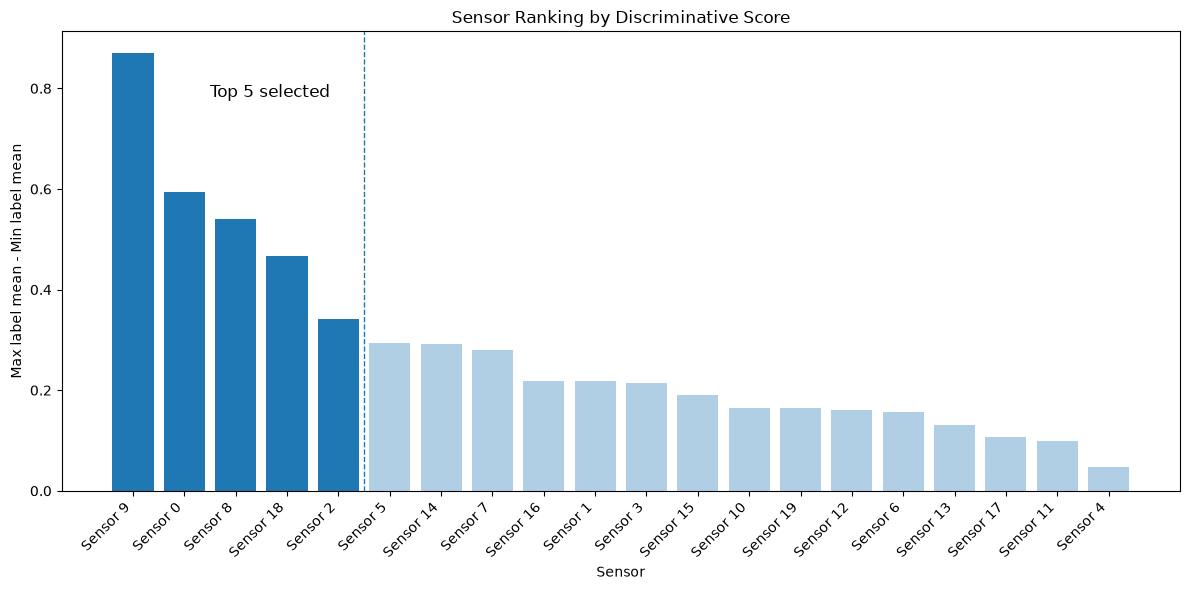

In [45]:
import matplotlib.pyplot as plt

# Compute how much each sensor differs across the known labels
sensor_discriminative_score = (
    sensor_means_by_label.max(axis=0) - sensor_means_by_label.min(axis=0)
)

sensor_ranking = sensor_discriminative_score.sort_values(ascending=False)
top_5_sensors = sensor_ranking.head(5).index.tolist()

plt.figure(figsize=(12, 6))

bars = plt.bar(
    sensor_ranking.index,
    sensor_ranking.values
)

# Highlight top 5 sensors
for bar, sensor in zip(bars, sensor_ranking.index):
    if sensor in top_5_sensors:
        bar.set_alpha(1.0)
    else:
        bar.set_alpha(0.35)

plt.title("Sensor Ranking by Discriminative Score")
plt.ylabel("Max label mean - Min label mean")
plt.xlabel("Sensor")
plt.xticks(rotation=45, ha="right")

plt.axvline(4.5, linestyle="--", linewidth=1)
plt.text(
    1.5,
    sensor_ranking.max() * 0.9,
    "Top 5 selected",
    fontsize=12
)

plt.tight_layout()
plt.savefig("../outputs/sensor_discriminative_ranking.png", dpi=300, bbox_inches="tight")
plt.show()

#### 4.2.2 Centroid Classification Using the Top 5 Discriminative Sensors

To reduce noise from less informative sensors, I repeated the centroid-based classification using only the top 5 sensors with the largest mean differences across the known labels.

In [46]:
top_5_sensors = sensor_ranking.head(5).index.tolist()
print(top_5_sensors)

['Sensor 9', 'Sensor 0', 'Sensor 8', 'Sensor 18', 'Sensor 2']


In [47]:
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from scipy.spatial.distance import cdist

loo_top5_preds = []

for i in range(len(labeled_df)):
    # Leave one labeled example out
    train_df = labeled_df.drop(labeled_df.index[i])

    # Re-select top 5 sensors from the training fold only (no leakage from held-out label)
    fold_means = train_df.groupby("Label")[sensor_columns].mean()
    fold_top5 = (fold_means.max(axis=0) - fold_means.min(axis=0)).nlargest(5).index.tolist()

    test_row = labeled_df.iloc[[i]][fold_top5]

    # Compute class centroids using only the selected sensors
    train_centroids = train_df.groupby("Label")[fold_top5].mean()

    # Compute distances from the held-out sample to each centroid
    dists = cdist(test_row, train_centroids.values, metric="euclidean")

    # Predict the label of the nearest centroid
    pred_label = train_centroids.index[np.argmin(dists)]
    loo_top5_preds.append(pred_label)

loo_top5_preds = np.array(loo_top5_preds)

print("Confusion matrix:")
print(confusion_matrix(labeled_df["Label"], loo_top5_preds))

print("\nClassification report:")
print(classification_report(labeled_df["Label"], loo_top5_preds))

print(f"Balanced accuracy: {balanced_accuracy_score(labeled_df['Label'], loo_top5_preds):.3f}")
print(f"Macro F1:          {f1_score(labeled_df['Label'], loo_top5_preds, average='macro'):.3f}")

Confusion matrix:
[[7 0 3]
 [1 5 4]
 [6 7 7]]

Classification report:
              precision    recall  f1-score   support

         1.0       0.50      0.70      0.58        10
         2.0       0.42      0.50      0.45        10
         3.0       0.50      0.35      0.41        20

    accuracy                           0.47        40
   macro avg       0.47      0.52      0.48        40
weighted avg       0.48      0.47      0.47        40

Balanced accuracy: 0.517
Macro F1:          0.483


In [48]:
from scipy.spatial.distance import cdist

# Compute label centroids using only the top 5 discriminative sensors
top5_centroids = labeled_df.groupby("Label")[top_5_sensors].mean()

# Compute distances from each unlabeled breakdown to each label centroid
top5_distances = cdist(
    df.loc[~labeled_mask, top_5_sensors],
    top5_centroids.values,
    metric="euclidean"
)

# Assign each unlabeled breakdown to the nearest centroid
top5_closest_idx = np.argmin(top5_distances, axis=1)
top5_predicted_labels = top5_centroids.index.to_numpy()[top5_closest_idx]

# Confidence margin = distance to second-closest centroid minus distance to closest centroid
sorted_top5_distances = np.sort(top5_distances, axis=1)
top5_margin = sorted_top5_distances[:, 1] - sorted_top5_distances[:, 0]

# Build results table
top5_results = df.loc[~labeled_mask].copy()
top5_results["Predicted_Label"] = top5_predicted_labels
top5_results["Margin"] = top5_margin

top5_results[["Predicted_Label", "Margin"]].head(10)

,Predicted_Label,Margin
0,3.0,0.010202
1,3.0,0.219194
2,2.0,0.539963
3,1.0,0.365642
4,1.0,0.280831
5,3.0,0.279748
7,2.0,0.389844
8,2.0,0.082652
9,3.0,0.137384
10,2.0,0.203874


In [49]:
print(top5_results["Predicted_Label"].value_counts().sort_index().to_string())
print(top5_results["Margin"].describe().to_string())
top5_high_conf = top5_results[top5_results["Margin"] >= 0.15]

print("High-confidence predictions:", len(top5_high_conf))
print()
print(top5_high_conf["Predicted_Label"].value_counts().sort_index().to_string())

Predicted_Label
1.0    458
2.0    557
3.0    545
count    1560.000000
mean        0.213636
std         0.168238
min         0.000201
25%         0.076407
50%         0.173858
75%         0.314332
max         0.796257
High-confidence predictions: 868

Predicted_Label
1.0    297
2.0    338
3.0    233


In [50]:
output_columns = top_5_sensors + ["Predicted_Label", "Margin"]

top5_results[output_columns].to_csv(
    "../outputs/top5_centroid_label_assignments.csv",
    index=False
)

In [51]:
from scipy.spatial.distance import cdist
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

loo_top5_preds = []
loo_top5_margins = []

for i in range(len(labeled_df)):
    # Leave one labeled example out
    train_df = labeled_df.drop(labeled_df.index[i])

    # Re-select top 5 sensors from the training fold only (no leakage from held-out label)
    fold_means = train_df.groupby("Label")[sensor_columns].mean()
    fold_top5 = (fold_means.max(axis=0) - fold_means.min(axis=0)).nlargest(5).index.tolist()

    test_row = labeled_df.iloc[[i]][fold_top5]

    # Compute class centroids using only the selected sensors
    train_centroids = train_df.groupby("Label")[fold_top5].mean()

    # Distances from the held-out sample to each centroid
    dists = cdist(test_row, train_centroids.values, metric="euclidean").flatten()

    # Predicted label = nearest centroid
    pred_label = train_centroids.index[np.argmin(dists)]
    loo_top5_preds.append(pred_label)

    # Margin = second-smallest distance - smallest distance
    sorted_dists = np.sort(dists)
    margin = sorted_dists[1] - sorted_dists[0]
    loo_top5_margins.append(margin)

loo_top5_preds = np.array(loo_top5_preds)
loo_top5_margins = np.array(loo_top5_margins)
y_true = labeled_df["Label"].to_numpy()

print("Overall accuracy: ", accuracy_score(y_true, loo_top5_preds))
print("Balanced accuracy:", balanced_accuracy_score(y_true, loo_top5_preds))
print("Macro F1:         ", f1_score(y_true, loo_top5_preds, average="macro"))

# Margin threshold analysis (larger margin = more confident prediction)
overall_acc = accuracy_score(y_true, loo_top5_preds)
print(f"\nMargin threshold analysis (overall LOO accuracy = {overall_acc:.3f}):")
print(f"{'Threshold':>10}  {'Coverage':>8}  {'n':>4}  {'Accuracy':>8}  {'Δ overall':>10}")
print("-" * 48)
for threshold in [0.10, 0.15, 0.20, 0.25]:
    mask = loo_top5_margins >= threshold
    n = int(mask.sum())
    if n == 0:
        print(f"{threshold:>10.2f}  {'—':>8}  {'—':>4}  {'—':>8}  {'—':>10}")
    else:
        cov = n / len(y_true)
        acc = accuracy_score(y_true[mask], loo_top5_preds[mask])
        delta = acc - overall_acc
        flag = "✓" if delta > 0 else "✗"
        print(f"{threshold:>10.2f}  {cov:>7.0%}  {n:>4}  {acc:>8.3f}  {delta:>+9.3f} {flag}")

Overall accuracy:  0.475
Balanced accuracy: 0.5166666666666666
Macro F1:          0.4832144979203803

Margin threshold analysis (overall LOO accuracy = 0.475):
 Threshold  Coverage     n  Accuracy   Δ overall
------------------------------------------------
      0.10      78%    31     0.516     +0.041 ✓
      0.15      70%    28     0.500     +0.025 ✓
      0.20      62%    25     0.480     +0.005 ✓
      0.25      48%    19     0.526     +0.051 ✓


### 4.3 Semi-Supervised Learning with Label Spreading

The previous experiments showed that pure clustering on the raw sensor space was weak, and that label-guided centroid classification improved performance when focusing on the most discriminative sensors.

As an additional experiment, I test a **semi-supervised** approach using **Label Spreading**.
This method uses both the 40 labeled failures and the 1560 unlabeled failures. It builds a similarity graph between all samples and propagates labels from labeled points to nearby unlabeled points based on feature similarity.

To evaluate it fairly, I use **leave-one-out validation** on the labeled subset: in each iteration, I hide one labeled example, train Label Spreading using the remaining labels plus all unlabeled data, and check whether the hidden label is recovered correctly.

#### 4.3.1 Label Spreading Using All 20 Sensors

Before restricting the feature space to the top 5 discriminative sensors, I evaluate Label Spreading on the full 20-sensor representation to check whether feature selection improves the semi-supervised model.

In [52]:
from sklearn.semi_supervised import LabelSpreading
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score

# Use all 20 sensor features
X_all = df.drop(columns=["Label"]).to_numpy()
y_full = df["Label"].copy()

labeled_indices = y_full[y_full.notna()].index.to_list()
y_true = y_full.loc[labeled_indices].to_numpy()

loo_ls_all_preds = []
loo_ls_all_conf = []

for idx in labeled_indices:
    # Hide one labeled sample and keep the rest as before
    y_train = y_full.copy()
    y_train.loc[idx] = np.nan
    y_train = y_train.fillna(-1).to_numpy()

    model = LabelSpreading(kernel="rbf", gamma=20, max_iter=1000)
    model.fit(X_all, y_train)

    pred_label = model.transduction_[idx]
    loo_ls_all_preds.append(pred_label)

    pred_proba = model.label_distributions_[idx]
    loo_ls_all_conf.append(pred_proba.max())

loo_ls_all_preds = np.array(loo_ls_all_preds)
loo_ls_all_conf = np.array(loo_ls_all_conf)

print("Overall accuracy: ", accuracy_score(y_true, loo_ls_all_preds))
print("Balanced accuracy:", balanced_accuracy_score(y_true, loo_ls_all_preds))
print("Macro F1:         ", f1_score(y_true, loo_ls_all_preds, average="macro"))

print("\nConfusion matrix:")
print(confusion_matrix(y_true, loo_ls_all_preds))

print("\nClassification report:")
print(classification_report(y_true, loo_ls_all_preds))

overall_acc = accuracy_score(y_true, loo_ls_all_preds)
print(f"\nConfidence threshold analysis (overall LOO accuracy = {overall_acc:.3f}):")
print(f"{'Threshold':>10}  {'Coverage':>8}  {'n':>4}  {'Accuracy':>8}  {'Δ overall':>10}")
print("-" * 48)
for threshold in [0.6, 0.7, 0.8, 0.9]:
    mask = loo_ls_all_conf >= threshold
    n = int(mask.sum())
    if n == 0:
        print(f"{threshold:>10.1f}  {'—':>8}  {'—':>4}  {'—':>8}  {'—':>10}")
    else:
        cov = n / len(y_true)
        acc = accuracy_score(y_true[mask], loo_ls_all_preds[mask])
        delta = acc - overall_acc
        flag = "✓" if delta > 0 else "✗"
        print(f"{threshold:>10.1f}  {cov:>7.0%}  {n:>4}  {acc:>8.3f}  {delta:>+9.3f} {flag}")

Overall accuracy:  0.425
Balanced accuracy: 0.3833333333333333
Macro F1:          0.3665022316185107

Confusion matrix:
[[ 5  0  5]
 [ 2  1  7]
 [ 5  4 11]]

Classification report:
              precision    recall  f1-score   support

         1.0       0.42      0.50      0.45        10
         2.0       0.20      0.10      0.13        10
         3.0       0.48      0.55      0.51        20

    accuracy                           0.42        40
   macro avg       0.36      0.38      0.37        40
weighted avg       0.39      0.42      0.40        40


Confidence threshold analysis (overall LOO accuracy = 0.425):
 Threshold  Coverage     n  Accuracy   Δ overall
------------------------------------------------
       0.6      92%    37     0.432     +0.007 ✓
       0.7      90%    36     0.444     +0.019 ✓
       0.8      85%    34     0.471     +0.046 ✓
       0.9      80%    32     0.438     +0.013 ✓


#### 4.3.2 Label Spreading Using Top-5 Sensors

In [53]:
from sklearn.semi_supervised import LabelSpreading
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score

y_full = df["Label"].copy()

labeled_indices = y_full[y_full.notna()].index.to_list()
y_true = y_full.loc[labeled_indices].to_numpy()

loo_ls_preds = []
loo_ls_conf = []

for idx in labeled_indices:
    # Re-select top 5 sensors from the training fold only (no leakage from held-out label)
    train_labeled_fold = labeled_df.drop(idx)
    fold_means = train_labeled_fold.groupby("Label")[sensor_columns].mean()
    fold_top5 = (fold_means.max(axis=0) - fold_means.min(axis=0)).nlargest(5).index.tolist()
    X_fold = df[fold_top5].to_numpy()

    # Create a semi-supervised label vector:
    # keep all existing labels except the held-out one, which becomes unlabeled (-1)
    y_train = y_full.copy()
    y_train.loc[idx] = np.nan
    y_train = y_train.fillna(-1).to_numpy()

    model = LabelSpreading(kernel="rbf", gamma=20, max_iter=1000)
    model.fit(X_fold, y_train)

    pred_label = model.transduction_[idx]
    loo_ls_preds.append(pred_label)

    # confidence = max predicted probability for the held-out sample
    pred_proba = model.label_distributions_[idx]
    loo_ls_conf.append(pred_proba.max())

loo_ls_preds = np.array(loo_ls_preds)
loo_ls_conf = np.array(loo_ls_conf)

print("Overall accuracy: ", accuracy_score(y_true, loo_ls_preds))
print("Balanced accuracy:", balanced_accuracy_score(y_true, loo_ls_preds))
print("Macro F1:         ", f1_score(y_true, loo_ls_preds, average="macro"))

print("\nConfusion matrix:")
print(confusion_matrix(y_true, loo_ls_preds))

print("\nClassification report:")
print(classification_report(y_true, loo_ls_preds))

overall_acc = accuracy_score(y_true, loo_ls_preds)
print(f"\nConfidence threshold analysis (overall LOO accuracy = {overall_acc:.3f}):")
print(f"{'Threshold':>10}  {'Coverage':>8}  {'n':>4}  {'Accuracy':>8}  {'Δ overall':>10}")
print("-" * 48)
for threshold in [0.6, 0.7, 0.8, 0.9]:
    mask = loo_ls_conf >= threshold
    n = int(mask.sum())
    if n == 0:
        print(f"{threshold:>10.1f}  {'—':>8}  {'—':>4}  {'—':>8}  {'—':>10}")
    else:
        cov = n / len(y_true)
        acc = accuracy_score(y_true[mask], loo_ls_preds[mask])
        delta = acc - overall_acc
        flag = "✓" if delta > 0 else "✗"
        print(f"{threshold:>10.1f}  {cov:>7.0%}  {n:>4}  {acc:>8.3f}  {delta:>+9.3f} {flag}")

Overall accuracy:  0.525
Balanced accuracy: 0.5
Macro F1:          0.5213639719453673

Confusion matrix:
[[ 5  0  5]
 [ 0  4  6]
 [ 1  7 12]]

Classification report:
              precision    recall  f1-score   support

         1.0       0.83      0.50      0.62        10
         2.0       0.36      0.40      0.38        10
         3.0       0.52      0.60      0.56        20

    accuracy                           0.53        40
   macro avg       0.57      0.50      0.52        40
weighted avg       0.56      0.53      0.53        40


Confidence threshold analysis (overall LOO accuracy = 0.525):
 Threshold  Coverage     n  Accuracy   Δ overall
------------------------------------------------
       0.6      95%    38     0.553     +0.028 ✓
       0.7      80%    32     0.500     -0.025 ✗
       0.8      60%    24     0.417     -0.108 ✗
       0.9      45%    18     0.444     -0.081 ✗


### 4.4 Weighted k-Nearest Neighbors

As another label-guided baseline, I test a weighted k-nearest-neighbors classifier, in which closer labeled examples have more influence on the prediction than more distant ones.

I first evaluate the model on the full 20-sensor representation, and then compare it to a reduced version that uses only the top 5 discriminative sensors in order to measure the impact of feature selection.

As in the previous experiments, I evaluate the model using leave-one-out validation on the labeled subset.

#### 4.4.1 Weighted kNN Using All 20 Sensors

In [54]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score

# Use all 20 sensor features for the labeled subset
X_labeled_all = labeled_df.drop(columns=["Label"]).to_numpy()
y_labeled_all = labeled_df["Label"].to_numpy()

loo_weighted_knn_all_preds = []
loo_weighted_knn_all_conf = []

for i in range(len(labeled_df)):
    # Leave one labeled example out
    train_mask = np.ones(len(labeled_df), dtype=bool)
    train_mask[i] = False

    X_train = X_labeled_all[train_mask]
    y_train = y_labeled_all[train_mask]
    X_test = X_labeled_all[[i]]

    model = KNeighborsClassifier(
        n_neighbors=5,
        weights="distance"
    )
    model.fit(X_train, y_train)

    pred = model.predict(X_test)[0]
    proba = model.predict_proba(X_test)[0].max()

    loo_weighted_knn_all_preds.append(pred)
    loo_weighted_knn_all_conf.append(proba)

loo_weighted_knn_all_preds = np.array(loo_weighted_knn_all_preds)
loo_weighted_knn_all_conf = np.array(loo_weighted_knn_all_conf)

print("Overall accuracy: ", accuracy_score(y_labeled_all, loo_weighted_knn_all_preds))
print("Balanced accuracy:", balanced_accuracy_score(y_labeled_all, loo_weighted_knn_all_preds))
print("Macro F1:         ", f1_score(y_labeled_all, loo_weighted_knn_all_preds, average="macro"))

print("\nConfusion matrix:")
print(confusion_matrix(y_labeled_all, loo_weighted_knn_all_preds))

print("\nClassification report:")
print(classification_report(y_labeled_all, loo_weighted_knn_all_preds))

overall_acc = accuracy_score(y_labeled_all, loo_weighted_knn_all_preds)
print(f"\nConfidence threshold analysis (overall LOO accuracy = {overall_acc:.3f}):")
print(f"{'Threshold':>10}  {'Coverage':>8}  {'n':>4}  {'Accuracy':>8}  {'Δ overall':>10}")
print("-" * 48)
for threshold in [0.6, 0.7, 0.8, 0.9]:
    mask = loo_weighted_knn_all_conf >= threshold
    n = int(mask.sum())
    if n == 0:
        print(f"{threshold:>10.1f}  {'—':>8}  {'—':>4}  {'—':>8}  {'—':>10}")
    else:
        cov = n / len(y_labeled_all)
        acc = accuracy_score(y_labeled_all[mask], loo_weighted_knn_all_preds[mask])
        delta = acc - overall_acc
        flag = "✓" if delta > 0 else "✗"
        print(f"{threshold:>10.1f}  {cov:>7.0%}  {n:>4}  {acc:>8.3f}  {delta:>+9.3f} {flag}")

Overall accuracy:  0.45
Balanced accuracy: 0.4333333333333333
Macro F1:          0.3897243107769423

Confusion matrix:
[[ 7  0  3]
 [ 4  1  5]
 [ 7  3 10]]

Classification report:
              precision    recall  f1-score   support

         1.0       0.39      0.70      0.50        10
         2.0       0.25      0.10      0.14        10
         3.0       0.56      0.50      0.53        20

    accuracy                           0.45        40
   macro avg       0.40      0.43      0.39        40
weighted avg       0.44      0.45      0.42        40


Confidence threshold analysis (overall LOO accuracy = 0.450):
 Threshold  Coverage     n  Accuracy   Δ overall
------------------------------------------------
       0.6      30%    12     0.500     +0.050 ✓
       0.7      22%     9     0.444     -0.006 ✗
       0.8       5%     2     0.500     +0.050 ✓
       0.9         —     —         —           —


#### 4.4.2 Weighted kNN Using the Top 5 Discriminative Sensors

In [55]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score

y_labeled_top5 = labeled_df["Label"].to_numpy()

loo_weighted_knn_preds = []
loo_weighted_knn_conf = []

for i in range(len(labeled_df)):
    # Leave one labeled example out
    train_df = labeled_df.drop(labeled_df.index[i])

    # Re-select top 5 sensors from the training fold only (no leakage from held-out label)
    fold_means = train_df.groupby("Label")[sensor_columns].mean()
    fold_top5 = (fold_means.max(axis=0) - fold_means.min(axis=0)).nlargest(5).index.tolist()
    X_labeled_fold = labeled_df[fold_top5].to_numpy()

    train_mask = np.ones(len(labeled_df), dtype=bool)
    train_mask[i] = False

    X_train = X_labeled_fold[train_mask]
    y_train = y_labeled_top5[train_mask]
    X_test = X_labeled_fold[[i]]

    # Weighted kNN: closer neighbors have stronger influence
    model = KNeighborsClassifier(
        n_neighbors=5,
        weights="distance"
    )
    model.fit(X_train, y_train)

    pred = model.predict(X_test)[0]
    proba = model.predict_proba(X_test)[0].max()

    loo_weighted_knn_preds.append(pred)
    loo_weighted_knn_conf.append(proba)

loo_weighted_knn_preds = np.array(loo_weighted_knn_preds)
loo_weighted_knn_conf = np.array(loo_weighted_knn_conf)

print("Overall accuracy: ", accuracy_score(y_labeled_top5, loo_weighted_knn_preds))
print("Balanced accuracy:", balanced_accuracy_score(y_labeled_top5, loo_weighted_knn_preds))
print("Macro F1:         ", f1_score(y_labeled_top5, loo_weighted_knn_preds, average="macro"))

print("\nConfusion matrix:")
print(confusion_matrix(y_labeled_top5, loo_weighted_knn_preds))

print("\nClassification report:")
print(classification_report(y_labeled_top5, loo_weighted_knn_preds))

overall_acc = accuracy_score(y_labeled_top5, loo_weighted_knn_preds)
print(f"\nConfidence threshold analysis (overall LOO accuracy = {overall_acc:.3f}):")
print(f"{'Threshold':>10}  {'Coverage':>8}  {'n':>4}  {'Accuracy':>8}  {'Δ overall':>10}")
print("-" * 48)
for threshold in [0.6, 0.7, 0.8, 0.9]:
    mask = loo_weighted_knn_conf >= threshold
    n = int(mask.sum())
    if n == 0:
        print(f"{threshold:>10.1f}  {'—':>8}  {'—':>4}  {'—':>8}  {'—':>10}")
    else:
        cov = n / len(y_labeled_top5)
        acc = accuracy_score(y_labeled_top5[mask], loo_weighted_knn_preds[mask])
        delta = acc - overall_acc
        flag = "✓" if delta > 0 else "✗"
        print(f"{threshold:>10.1f}  {cov:>7.0%}  {n:>4}  {acc:>8.3f}  {delta:>+9.3f} {flag}")

Overall accuracy:  0.475
Balanced accuracy: 0.4333333333333333
Macro F1:          0.43568815085842943

Confusion matrix:
[[ 5  0  5]
 [ 1  2  7]
 [ 3  5 12]]

Classification report:
              precision    recall  f1-score   support

         1.0       0.56      0.50      0.53        10
         2.0       0.29      0.20      0.24        10
         3.0       0.50      0.60      0.55        20

    accuracy                           0.47        40
   macro avg       0.45      0.43      0.44        40
weighted avg       0.46      0.47      0.46        40


Confidence threshold analysis (overall LOO accuracy = 0.475):
 Threshold  Coverage     n  Accuracy   Δ overall
------------------------------------------------
       0.6      65%    26     0.500     +0.025 ✓
       0.7      32%    13     0.615     +0.140 ✓
       0.8      30%    12     0.667     +0.192 ✓
       0.9       8%     3     0.667     +0.192 ✓


### Takeaway

Using the 40 labeled failures improved performance compared to pure clustering, but the strongest gains came from **feature selection**.
Restricting the analysis to the top 5 discriminative sensors improved all of the stronger label-guided models: centroid-based classification improved from **0.33 to 0.475**, weighted kNN improved from **0.45 to 0.475**, and Label Spreading improved from **0.425 to 0.525**.

Among the label-guided and semi-supervised models, **Label Spreading on the top 5 sensors** achieved the best leave-one-out accuracy (0.525). However, fully supervised baselines have not yet been evaluated — Section 5 tests whether a supervised model can match or exceed this result.

> **Note on evaluation:** sensor selection is re-computed inside each leave-one-out fold (using only the 39 training samples), so the held-out label does not influence feature selection.

## 5. Supervised Baselines: Logistic Regression and Random Forest

The label-guided and semi-supervised models in Section 4 were not compared against any fully supervised classifier. Before selecting a final model, I test whether Logistic Regression and Random Forest — trained only on the 40 labeled samples, without access to any unlabeled data — can match or exceed the best semi-supervised result (Label Spreading: 0.525 LOO accuracy).

Both models are evaluated with leave-one-out cross-validation on the top-5 discriminative sensors, using the same protocol as Section 4.

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score

X_labeled_top5 = labeled_df[top_5_sensors].to_numpy()
y_labeled = labeled_df["Label"].to_numpy()

# --- Logistic Regression (LOO) ---
lr_preds, lr_conf = [], []
for i in range(len(labeled_df)):
    mask = np.ones(len(labeled_df), dtype=bool)
    mask[i] = False
    clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    clf.fit(X_labeled_top5[mask], y_labeled[mask])
    lr_preds.append(clf.predict(X_labeled_top5[[i]])[0])
    lr_conf.append(clf.predict_proba(X_labeled_top5[[i]])[0].max())
lr_preds = np.array(lr_preds)
lr_conf  = np.array(lr_conf)

# --- Random Forest (LOO) ---
rf_preds, rf_conf = [], []
for i in range(len(labeled_df)):
    mask = np.ones(len(labeled_df), dtype=bool)
    mask[i] = False
    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_labeled_top5[mask], y_labeled[mask])
    rf_preds.append(clf.predict(X_labeled_top5[[i]])[0])
    rf_conf.append(clf.predict_proba(X_labeled_top5[[i]])[0].max())
rf_preds = np.array(rf_preds)
rf_conf  = np.array(rf_conf)

# --- Print metrics ---
for name, preds, confs in [
    ("Logistic Regression", lr_preds, lr_conf),
    ("Random Forest",       rf_preds, rf_conf),
]:
    overall_acc = accuracy_score(y_labeled, preds)
    print("=" * 60)
    print(name)
    print(f"Overall accuracy:  {overall_acc:.3f}")
    print(f"Balanced accuracy: {balanced_accuracy_score(y_labeled, preds):.3f}")
    print(f"Macro F1:          {f1_score(y_labeled, preds, average='macro'):.3f}")
    print("\nConfusion matrix:")
    print(confusion_matrix(y_labeled, preds))
    print("\nClassification report:")
    print(classification_report(y_labeled, preds))
    print(f"\nConfidence threshold analysis (overall LOO accuracy = {overall_acc:.3f}):")
    print(f"{'Threshold':>10}  {'Coverage':>8}  {'n':>4}  {'Accuracy':>8}  {'\u0394 overall':>10}")
    print("-" * 48)
    for threshold in [0.6, 0.7, 0.8, 0.9]:
        mask_t = confs >= threshold
        n = int(mask_t.sum())
        if n == 0:
            print(f"{threshold:>10.1f}  {'\u2014':>8}  {'\u2014':>4}  {'\u2014':>8}  {'\u2014':>10}")
        else:
            cov = n / len(y_labeled)
            acc = accuracy_score(y_labeled[mask_t], preds[mask_t])
            delta = acc - overall_acc
            flag = "\u2713" if delta > 0 else "\u2717"
            print(f"{threshold:>10.1f}  {cov:>7.0%}  {n:>4}  {acc:>8.3f}  {delta:>+9.3f} {flag}")
    print()


Logistic Regression
Overall accuracy:  0.600
Balanced accuracy: 0.550
Macro F1:          0.564

Confusion matrix:
[[ 5  0  5]
 [ 1  4  5]
 [ 2  3 15]]

Classification report:
              precision    recall  f1-score   support

         1.0       0.62      0.50      0.56        10
         2.0       0.57      0.40      0.47        10
         3.0       0.60      0.75      0.67        20

    accuracy                           0.60        40
   macro avg       0.60      0.55      0.56        40
weighted avg       0.60      0.60      0.59        40


Confidence threshold analysis (overall LOO accuracy = 0.600):
 Threshold  Coverage     n  Accuracy   Δ overall
------------------------------------------------
       0.6      45%    18     0.778     +0.178 ✓
       0.7      30%    12     0.833     +0.233 ✓
       0.8       8%     3     0.667     +0.067 ✓
       0.9         —     —         —           —

Random Forest
Overall accuracy:  0.725
Balanced accuracy: 0.717
Macro F1:          0.7

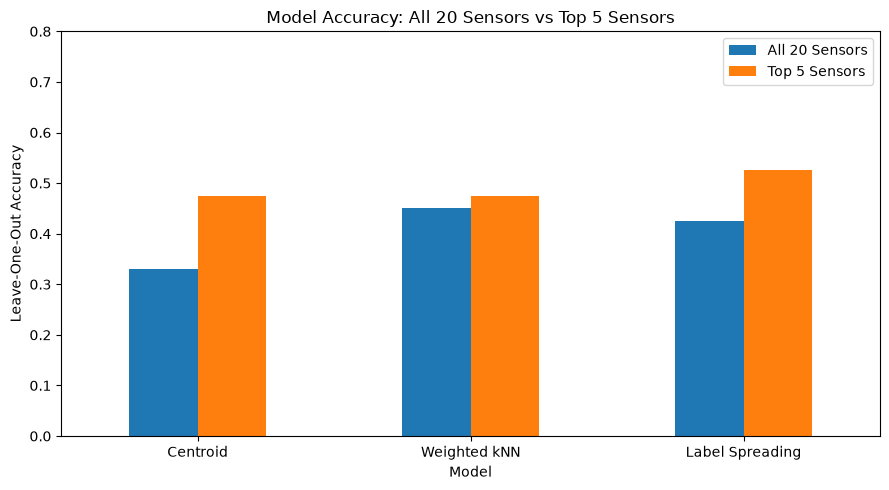

Top-5 sensor models — leave-one-out metrics
Majority-class baseline: accuracy=0.50, balanced acc=0.33, macro F1=0.22

                     Accuracy  Balanced Acc.  Macro F1
Model                                                 
Centroid                0.475          0.517     0.483
Weighted kNN            0.475          0.433     0.436
Label Spreading         0.525          0.500     0.521
Logistic Regression     0.600          0.550     0.564
Random Forest           0.725          0.717     0.723


In [57]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

comparison_df = pd.DataFrame({
    "Model": ["Centroid", "Weighted kNN", "Label Spreading"],
    "All 20 Sensors": [0.33, 0.45, 0.425],
    "Top 5 Sensors": [0.475, 0.475, 0.525],
})

ax = comparison_df.set_index("Model").plot(kind="bar", figsize=(9, 5))
plt.title("Model Accuracy: All 20 Sensors vs Top 5 Sensors")
plt.ylabel("Leave-One-Out Accuracy")
plt.ylim(0, 0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/model_comparison_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

# All metrics for all top-5 sensor models (semi-supervised and supervised baselines)
y_all = labeled_df["Label"].to_numpy()
metrics_df = pd.DataFrame({
    "Model": ["Centroid", "Weighted kNN", "Label Spreading", "Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_all, loo_top5_preds),
        accuracy_score(y_all, loo_weighted_knn_preds),
        accuracy_score(y_all, loo_ls_preds),
        accuracy_score(y_all, lr_preds),
        accuracy_score(y_all, rf_preds),
    ],
    "Balanced Acc.": [
        balanced_accuracy_score(y_all, loo_top5_preds),
        balanced_accuracy_score(y_all, loo_weighted_knn_preds),
        balanced_accuracy_score(y_all, loo_ls_preds),
        balanced_accuracy_score(y_all, lr_preds),
        balanced_accuracy_score(y_all, rf_preds),
    ],
    "Macro F1": [
        f1_score(y_all, loo_top5_preds, average="macro"),
        f1_score(y_all, loo_weighted_knn_preds, average="macro"),
        f1_score(y_all, loo_ls_preds, average="macro"),
        f1_score(y_all, lr_preds, average="macro"),
        f1_score(y_all, rf_preds, average="macro"),
    ],
})

print("Top-5 sensor models — leave-one-out metrics")
print("Majority-class baseline: accuracy=0.50, balanced acc=0.33, macro F1=0.22\n")
print(metrics_df.set_index("Model").round(3).to_string())


### Takeaway

Both supervised models outperformed all label-guided and semi-supervised approaches on every metric. Random Forest achieved LOO accuracy **0.725**, balanced accuracy **0.717**, and macro F1 **0.723** — substantially above Label Spreading's 0.525. Its confidence scores were also well-calibrated: accuracy increased monotonically with the confidence threshold, reaching **1.000** on the top-25% most confident LOO predictions.

The 1,560 unlabeled samples did not improve performance over a supervised model trained on the 40 labeled failures alone. **Random Forest on the top-5 sensors is selected as the final model.**

## 6. Final Label Assignment with Random Forest

Random Forest on the top-5 sensors achieved the strongest leave-one-out performance across all evaluated models (accuracy 0.725, balanced accuracy 0.717). I now train it on all 40 labeled failures and use it to assign predicted labels to the 1,560 unlabeled machine breakdowns.

In [58]:
from sklearn.ensemble import RandomForestClassifier

# Train the final Random Forest model on all 40 labeled samples
# using the top 5 most discriminative sensors
X_labeled_top5_final = labeled_df[top_5_sensors].to_numpy()
y_labeled_final = labeled_df["Label"].to_numpy()

final_rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
final_rf_model.fit(X_labeled_top5_final, y_labeled_final)

# Predict labels and confidence scores for all unlabeled failures
X_unlabeled_top5 = df.loc[~labeled_mask, top_5_sensors].to_numpy()

final_unlabeled_results = df.loc[~labeled_mask].copy()
final_unlabeled_results["Predicted_Label"] = final_rf_model.predict(X_unlabeled_top5)
final_unlabeled_results["Confidence"] = final_rf_model.predict_proba(X_unlabeled_top5).max(axis=1)

final_unlabeled_results[["Predicted_Label", "Confidence"]].head(10)

,Predicted_Label,Confidence
0,2.0,0.485
1,1.0,0.650
2,2.0,0.810
3,1.0,0.805
4,1.0,0.650
5,3.0,0.485
7,2.0,0.855
8,2.0,0.625
9,1.0,0.765
10,3.0,0.415


In [59]:
print(final_unlabeled_results["Predicted_Label"].value_counts().sort_index().to_string())
print(final_unlabeled_results["Confidence"].describe().to_string())

for threshold in [0.7, 0.8]:
    hc = final_unlabeled_results[final_unlabeled_results["Confidence"] >= threshold]
    print(f"\nHigh-confidence predictions (\u2265 {threshold}): {len(hc)}")
    print(hc["Predicted_Label"].value_counts().sort_index().to_string())

output_columns = top_5_sensors + ["Predicted_Label", "Confidence"]
final_unlabeled_results[output_columns].to_csv(
    "../outputs/final_rf_predictions.csv",
    index=False
)

Predicted_Label
1.0    633
2.0    489
3.0    438
count    1560.000000
mean        0.632923
std         0.139742
min         0.340000
25%         0.515000
50%         0.620000
75%         0.740000
max         0.980000

High-confidence predictions (≥ 0.7): 524
Predicted_Label
1.0    204
2.0    200
3.0    120

High-confidence predictions (≥ 0.8): 237
Predicted_Label
1.0    101
2.0     60
3.0     76


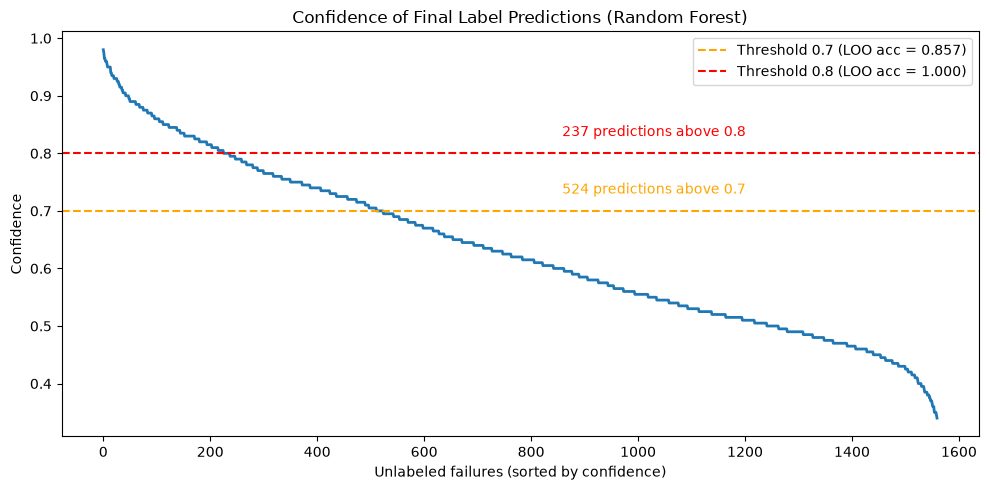

In [60]:
import matplotlib.pyplot as plt

sorted_conf = (
    final_unlabeled_results["Confidence"]
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

n_high_conf_07 = (final_unlabeled_results["Confidence"] >= 0.7).sum()
n_high_conf_08 = (final_unlabeled_results["Confidence"] >= 0.8).sum()

plt.figure(figsize=(10, 5))
plt.plot(sorted_conf.values, linewidth=2)
plt.axhline(0.7, color="orange", linestyle="--", label="Threshold 0.7 (LOO acc = 0.857)")
plt.axhline(0.8, color="red",    linestyle="--", label="Threshold 0.8 (LOO acc = 1.000)")

plt.text(len(sorted_conf) * 0.55, 0.73,
         f"{n_high_conf_07} predictions above 0.7", fontsize=10, color="orange")
plt.text(len(sorted_conf) * 0.55, 0.83,
         f"{n_high_conf_08} predictions above 0.8", fontsize=10, color="red")

plt.title("Confidence of Final Label Predictions (Random Forest)")
plt.xlabel("Unlabeled failures (sorted by confidence)")
plt.ylabel("Confidence")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/final_prediction_confidence_curve.png", dpi=300, bbox_inches="tight")
plt.show()

### Takeaway

The final Random Forest model was used to assign predicted labels to all 1,560 unlabeled machine failures.
The leave-one-out confidence calibration showed that at threshold 0.7 the model achieved **0.857 accuracy on 35% of predictions**, providing a reliable triage signal for expert review.

> **Caveat:** These confidence estimates are based on leave-one-out evaluation on 40 labeled samples. They should be treated as indicative rather than definitive until validated on additional labeled data.

## 7. Summary of Findings

I first evaluated several unsupervised clustering baselines on the 20 raw sensor values, including KMeans, Agglomerative Clustering, and Gaussian Mixture Models. None of them produced a clean separation of the three known failure classes, and silhouette scores remained very low.

I then moved to label-guided approaches using the 40 expert-labeled failures. A nearest-neighbor approach on all 20 sensors performed poorly, and a centroid-based classifier using all sensors also gave limited performance. This suggested that the raw sensor space was noisy and that not all sensors contributed equally to failure type separation.

To address this, I ranked sensors by how strongly their mean values differed across the three known labels and selected the top 5 most discriminative sensors. Restricting the analysis to these sensors improved all of the stronger label-guided models. In leave-one-out evaluation — with sensor selection re-computed per fold to avoid leakage — centroid-based classification improved from **0.33 to 0.475**, weighted kNN improved from **0.45 to 0.475**, and Label Spreading improved from **0.425 to 0.525**.

To test whether the semi-supervised framing was necessary, I evaluated two fully supervised classifiers on the same top-5 features: Logistic Regression achieved LOO accuracy **0.600** (balanced acc. **0.550**), and Random Forest achieved LOO accuracy **0.725** (balanced acc. **0.717**). Both outperformed Label Spreading on every metric, despite training only on the 40 labeled samples per fold and without access to any unlabeled data. This shows that the top-5 sensors are discriminative enough for a supervised model to learn effective class boundaries directly.

The confidence calibration analysis further supported this conclusion. Label Spreading's confidence scores were non-monotonic and anti-correlated with accuracy above threshold 0.6. Random Forest confidence was well-calibrated: at threshold 0.7 the model achieved **0.857 accuracy on 35% of LOO predictions**; at threshold 0.8, **1.000 accuracy on 25% of LOO predictions**.

Based on these results, the final selected model is **Random Forest on the top 5 sensors**. It was trained on all 40 labeled failures and used to assign predicted labels to all 1,560 unlabeled machine breakdowns.

> **Caveat on interpretation:** With only 40 labeled samples (roughly 13 per class), leave-one-out estimates carry meaningful variance. The Random Forest advantage over Label Spreading corresponds to 8 additional correct predictions out of 40. These results are promising but should be validated with additional labeled data before production use.